# Dataset & Priorities Explorer

Interactive workbench for the continuous-target MINLP experiment. It lets you:

1. Pick a **dataset**, a **split** (`test` / `train` / `entire`) and whether to view
   **raw** or **preprocessed** features.
2. Optionally select a set of **samples** (by row index) and, per sample, an optional
   **target** (a desired scaled prediction in `[0, 1]`). A target is resolved to its
   closest-prediction dataset row (an *exemplar*) and linked to its sample by a line.
3. Explore **1D** and **2D** feature distributions (you choose which feature is
   continuous vs categorical).
4. Author **priorities** in a plain editable dict (same shape as `priority_sets.py`,
   ready to copy back) and see how they cover the dataset.

> Run cells top-to-bottom. After changing the dataset/split/mode in the Setup cell and
> clicking **Load dataset**, re-run the plotting cells so their widgets pick up the new
> feature list.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from IPython.display import display, clear_output

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "explainit").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp.data_setup import (
    load_dataset, DATASETS, _dataset_path,
)
from explainit.experiments.continuous_minlp.model_setup import load_model
from explainit.experiments.continuous_minlp.priority_sets import (
    ExperimentContext, build_priorities, PRIORITY_SETS,
    linear_priority, exponential_priority, constant_priority,
    interval_priority, numerical_entry, NON_ACTIONABLE,
)
from explainit.utils.priorities_analyser import (
    compute_priority_coverage, format_coverage_report, find_closest_exemplars,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("Imports ready. Project root:", PROJECT_ROOT)

2026-07-01 09:46:39,640 - DEBUG - tensorflow - Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-07-01 09:46:40,013 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-01 09:46:40,014 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-01 09:46:40,014 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-01 09:46:40,014 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-01 09:46:40,783 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-07-01 09:46:40,784 - DEBUG - matplotlib.pyplot - Loaded backend inline version unknown.


Imports ready. Project root: /Users/bartosz/projects/explainit/explainit_project


## 1. Setup: dataset, split, view mode

Pick the dataset, the split to analyse and whether to look at the **raw** features
(original units, categoricals as single columns) or the **preprocessed** features
(numericals standard-scaled, categoricals one-hot). Click **Load dataset**.

In [2]:
try:
    import ipywidgets as _w
    _w.Widget.close_all()
except Exception:
    pass
clear_output(wait=True)

STATE = {}


def current():
    if not STATE:
        raise RuntimeError("Run the Setup cell and click 'Load dataset' first.")
    return STATE


def _as_array(a):
    return a.values if hasattr(a, "values") else np.asarray(a)


def scolor(i):
    return plt.get_cmap("tab10")(i % 10)


def available_datasets():
    return [k for k in sorted(DATASETS) if _dataset_path(k).exists()]


def build_working_data(dataset_key, split, mode):
    data = load_dataset(dataset_key)
    model = load_model(dataset_key)

    feature_names = [str(n) for n in data["feature_names"]]
    numerical_features = [str(n) for n in data.get("numerical_features", [])]
    categorical_groups = dict(data.get("categorical_groups", {}) or {})
    target_name = str(data.get("target_name", "target"))

    Xtr = _as_array(data["X_train"]).astype(float)
    Xte = _as_array(data["X_test"]).astype(float)
    ytr = np.asarray(data["y_train"], float).flatten()
    yte = np.asarray(data["y_test"], float).flatten()
    Xtr_raw = data["X_train_raw"].reset_index(drop=True)
    Xte_raw = data["X_test_raw"].reset_index(drop=True)
    ytr_raw = np.asarray(data["y_train_raw"], float).flatten()
    yte_raw = np.asarray(data["y_test_raw"], float).flatten()

    if split == "train":
        pre, y_scaled = Xtr, ytr
        raw_df, y_raw = Xtr_raw, ytr_raw
    elif split == "test":
        pre, y_scaled = Xte, yte
        raw_df, y_raw = Xte_raw, yte_raw
    else:
        pre = np.vstack([Xtr, Xte])
        y_scaled = np.concatenate([ytr, yte])
        raw_df = pd.concat([Xtr_raw, Xte_raw], ignore_index=True)
        y_raw = np.concatenate([ytr_raw, yte_raw])

    if mode == "raw":
        display_df = raw_df.reset_index(drop=True).copy()
        display_feature_names = [str(c) for c in display_df.columns]
        display_y = y_raw
        cat_names = set(categorical_groups.keys())
        default_kinds = {
            c: ("categorical" if c in cat_names else "continuous")
            for c in display_feature_names
        }
        y_label = target_name + " (raw)"
    else:
        display_df = pd.DataFrame(pre, columns=feature_names)
        display_feature_names = list(feature_names)
        display_y = y_scaled
        onehot_cols = set()
        for g in categorical_groups.values():
            onehot_cols.update(g["columns"])
        default_kinds = {
            c: ("categorical" if c in onehot_cols else "continuous")
            for c in display_feature_names
        }
        y_label = target_name + " (scaled [0,1])"

    target_col = target_name if target_name not in display_df.columns else f"{target_name}__target"
    display_df = display_df.copy()
    display_df[target_col] = display_y
    display_feature_names = list(display_feature_names) + [target_col]
    default_kinds[target_col] = "continuous"

    ctx = ExperimentContext(
        dataset_key=dataset_key, model=model, feature_names=feature_names,
        X_train=Xtr, X_test=Xte, y_train=ytr, y_test=yte,
        target_name=target_name,
        numerical_features=numerical_features,
        categorical_groups=categorical_groups,
    )

    STATE.clear()
    STATE.update(dict(
        dataset_key=dataset_key, split=split, mode=mode,
        model=model, ctx=ctx,
        pre_matrix=pre,
        display_df=display_df.reset_index(drop=True),
        display_feature_names=display_feature_names,
        display_y=display_y,
        feature_names=feature_names,
        numerical_features=numerical_features,
        categorical_groups=categorical_groups,
        default_kinds=default_kinds,
        y_label=y_label, target_name=target_name,
        target_col=target_col,
        samples=[],
    ))
    return STATE


_ds = available_datasets()
dataset_dd = widgets.Dropdown(options=_ds, value=(_ds[0] if _ds else None),
                              description="Dataset:")
split_dd = widgets.Dropdown(options=["test", "train", "entire"], value="test",
                            description="Split:")
mode_dd = widgets.Dropdown(options=["preprocessed", "raw"], value="preprocessed",
                           description="View:")
load_btn = widgets.Button(description="Reload (apply selections)", button_style="primary")


def _redraw_setup():
    clear_output(wait=True)
    display(widgets.HBox([dataset_dd, split_dd, mode_dd]))
    display(load_btn)
    st = STATE
    if not st:
        print("No dataset loaded.")
        return
    df = st["display_df"]
    print(f"Loaded '{st['dataset_key']}' | split={st['split']} | view={st['mode']}")
    print(f"Rows: {len(df)} | Display features ({len(df.columns)}): {list(df.columns)}")
    cont = [f for f, k in st["default_kinds"].items() if k == "continuous"]
    cat = [f for f, k in st["default_kinds"].items() if k == "categorical"]
    print(f"Default continuous: {cont}")
    print(f"Default categorical: {cat}")
    print("Target:", st["y_label"])


def _on_load(_=None):
    build_working_data(dataset_dd.value, split_dd.value, mode_dd.value)
    _redraw_setup()


load_btn.on_click(_on_load)

if _ds:
    build_working_data(dataset_dd.value, split_dd.value, mode_dd.value)
    _redraw_setup()
else:
    display(widgets.HBox([dataset_dd, split_dd, mode_dd]))
    display(load_btn)
    print("No prepared datasets found. Run data_setup.py first.")


Button(button_style='primary', description='Reload (apply selections)', style=ButtonStyle())

### Browse the dataset

The cell below displays the loaded DataFrame. Use pandas filtering directly
(`df[df['bmi'] > 0]`, `df.describe()`, etc.) to explore. Then define your
samples in the next cell as a plain Python list of dicts.

In [3]:
# Display the loaded DataFrame. You can filter / query / describe inline.
st = current()
st["display_df"]

,age,sex=0,sex=1,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,1.498365,0.0,1.0,0.219902,1.138874,0.728473,1.055893,-0.824451,0.711038,0.547482,-0.061449,0.370717
1,-0.228858,0.0,1.0,-0.419366,-0.710591,-0.424929,0.272425,-1.529791,1.484286,-0.019757,0.367236,0.389408
2,0.085182,1.0,0.0,1.018987,1.992473,-0.309589,-0.326699,-0.119111,-0.062210,0.331237,-0.318660,0.794393
3,-0.621409,1.0,0.0,-0.784662,-0.639458,-1.174640,-1.215508,0.664600,-0.835458,-1.069682,-2.719299,0.311526
4,-0.542899,1.0,0.0,-1.423930,-1.706457,-0.799784,-1.110167,1.291569,-1.608706,-0.802859,-0.918820,0.105919
...,...,...,...,...,...,...,...,...,...,...,...,...
437,0.006672,1.0,0.0,-1.423930,-0.141525,-0.136578,-0.392536,0.899714,-0.835458,-0.094574,0.110025,0.398754
438,0.242203,1.0,0.0,-0.579183,-0.852858,-0.626774,-0.932406,1.683425,-1.608706,-1.535764,0.195762,0.227414
439,-0.621409,1.0,0.0,-1.378268,-1.066257,-1.866681,-2.176738,1.134827,-1.608706,-1.201185,-1.433242,0.037383
440,-0.542899,1.0,0.0,-1.515254,-1.350790,-1.232310,-1.044330,0.429487,-0.835458,-1.891720,-1.090294,0.118380


### Define samples

Edit the `SAMPLES` list below, then run the cell. Each entry is a dict:

```python
{"idx": 0}                   # sample only, no target
{"idx": 5, "target": 0.75}   # sample with desired scaled target
```

A target is resolved to the dataset row whose model prediction is closest
(the *exemplar*), shown on every plot linked to its sample by a line.
Leave the list empty for no overlays.

In [4]:
# === EDIT ME: define samples to overlay on plots ===
SAMPLES = [
    # {"idx": 0},
    # {"idx": 5, "target": 0.75},
    # {"idx": 12, "target": 0.25},
]


def apply_samples_from_list(samples_list):
    st = current()
    n = len(st["display_df"])
    result = []
    for spec in samples_list:
        idx = spec["idx"]
        if not (0 <= idx < n):
            print(f"  skip out-of-range index {idx} (split has {n} rows)")
            continue
        s = dict(idx=idx, target=spec.get("target"),
                 display_row=st["display_df"].iloc[idx],
                 pre_vector=st["pre_matrix"][idx])
        tgt = spec.get("target")
        if tgt is not None:
            ex = find_closest_exemplars(st["model"], st["pre_matrix"], float(tgt), k=1)
            if ex:
                s["exemplar_idx"] = ex[0].row_index
                s["exemplar_row"] = st["display_df"].iloc[ex[0].row_index]
                s["exemplar_pred"] = ex[0].prediction
        result.append(s)
    st["samples"] = result
    if not result:
        print("No samples set (overlays will be empty).")
    for s in result:
        line = f"sample idx={s['idx']}"
        if s.get("target") is not None:
            ex = s.get("exemplar_idx")
            line += (f" | target={s['target']:.4f} -> exemplar row={ex} "
                     f"(pred={s.get('exemplar_pred', float('nan')):.4f})")
        print(line)
    return result


apply_samples_from_list(SAMPLES)

No samples set (overlays will be empty).


[]

## 2. 1D distribution

Select one feature and mark it continuous or categorical (you decide; the dropdown just
defaults to a guess). Continuous -> histogram. Categorical -> per-value counts. Toggle
the sample/target overlays.

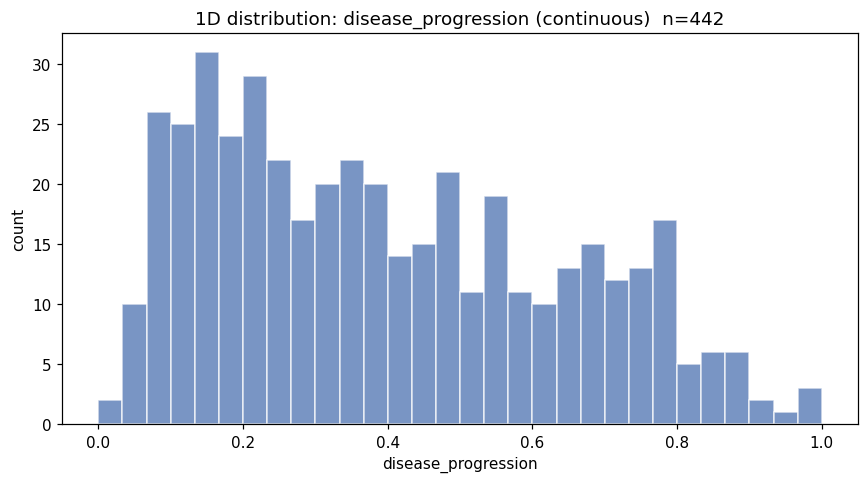

In [ ]:
try:
    import ipywidgets as _w
    _w.Widget.close_all()
except Exception:
    pass
clear_output(wait=True)


def plot_1d(feature, kind, bins, logy, show_samples, show_targets):
    st = current()
    col = st["display_df"][feature]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    cat_to_x = {}
    if kind == "continuous":
        vals = pd.to_numeric(col, errors="coerce").dropna().values
        ax.hist(vals, bins=bins, color="#4C72B0", alpha=0.75, edgecolor="white")
        ax.set_ylabel("count")
        n_pts = len(vals)
    else:
        counts = col.value_counts().sort_index()
        cat_to_x = {c: i for i, c in enumerate(counts.index)}
        xpos = np.arange(len(counts))
        ax.bar(xpos, counts.values, color="#55A868", alpha=0.85)
        ax.set_xticks(xpos)
        n_pts = int(counts.sum())
        ax.set_xticklabels([str(c) for c in counts.index])
        ax.set_ylabel("count")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(feature)
    ymax = ax.get_ylim()[1]
    for i, s in enumerate(st["samples"]):
        c = scolor(i)
        sv = s["display_row"][feature]
        ev = s["exemplar_row"][feature] if "exemplar_row" in s else None
        if kind == "continuous":
            if show_samples:
                ax.axvline(float(sv), color=c, ls="--", lw=1.8)
                ax.text(float(sv), ymax * 0.99, f"s{s['idx']}", color=c,
                        ha="center", va="top", fontsize=8)
            if show_targets and ev is not None:
                ax.axvline(float(ev), color=c, ls=":", lw=1.8)
                ax.text(float(ev), ymax * 0.90, f"t{s['idx']}", color=c,
                        ha="center", va="top", fontsize=8)
                if show_samples:
                    ax.plot([float(sv), float(ev)], [ymax * 0.94, ymax * 0.94],
                            color=c, alpha=0.5, lw=1.2)
        else:
            if show_samples and sv in cat_to_x:
                x = cat_to_x[sv]
                ax.scatter([x], [ymax * 0.96], color=c, marker="v", s=70, zorder=5)
                ax.text(x, ymax * 0.99, f"s{s['idx']}", color=c,
                        ha="center", va="top", fontsize=8)
            if show_targets and ev is not None and ev in cat_to_x:
                x = cat_to_x[ev]
                ax.scatter([x], [ymax * 0.86], color=c, marker="o",
                           facecolors="none", s=70, zorder=5)
                ax.text(x, ymax * 0.89, f"t{s['idx']}", color=c,
                        ha="center", va="top", fontsize=8)
    ax.set_title(f"1D distribution: {feature} ({kind})  n={n_pts}")
    plt.tight_layout()
    plt.show()


st = current()
_feats = st["display_feature_names"]
feat_dd = widgets.Dropdown(options=_feats, description="Feature:")
kind_dd = widgets.Dropdown(options=["continuous", "categorical"], description="Kind:",
                           value=st["default_kinds"][_feats[0]])
bins_sl = widgets.IntSlider(value=30, min=5, max=100, description="Bins:")
logy_cb = widgets.Checkbox(value=False, description="log y")
show_s_cb = widgets.Checkbox(value=True, description="show samples")
show_t_cb = widgets.Checkbox(value=True, description="show targets")
plot_btn = widgets.Button(description="Plot", button_style="primary")

feat_dd.observe(lambda ch: setattr(kind_dd, "value",
                st["default_kinds"].get(ch["new"], "continuous")), names="value")


def _redraw_1d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([feat_dd, kind_dd]))
    display(widgets.HBox([bins_sl, logy_cb]))
    display(widgets.HBox([show_s_cb, show_t_cb, plot_btn]))
    print(f"Number of configured samples: {len(current()['samples'])}")
    if make_plot:
        plot_1d(feat_dd.value, kind_dd.value, bins_sl.value, logy_cb.value,
                show_s_cb.value, show_t_cb.value)


def _on_plot_1d(_=None):
    _redraw_1d(make_plot=True)


plot_btn.on_click(_on_plot_1d)
_redraw_1d(make_plot=False)


## 3. 2D distribution

Pick two features and mark each continuous/categorical:

* **continuous + continuous** -> 2D histogram (optional log colour scale),
* **continuous + categorical** -> one histogram of the continuous feature per category
  (shared x-range),
* **categorical + categorical** -> grouped counts (for each X category, a bar per Y
  category).

Overlays: samples are drawn as points/lines; targets as their exemplars, linked to the
sample by a line (in the 2D-histogram and category-count views).

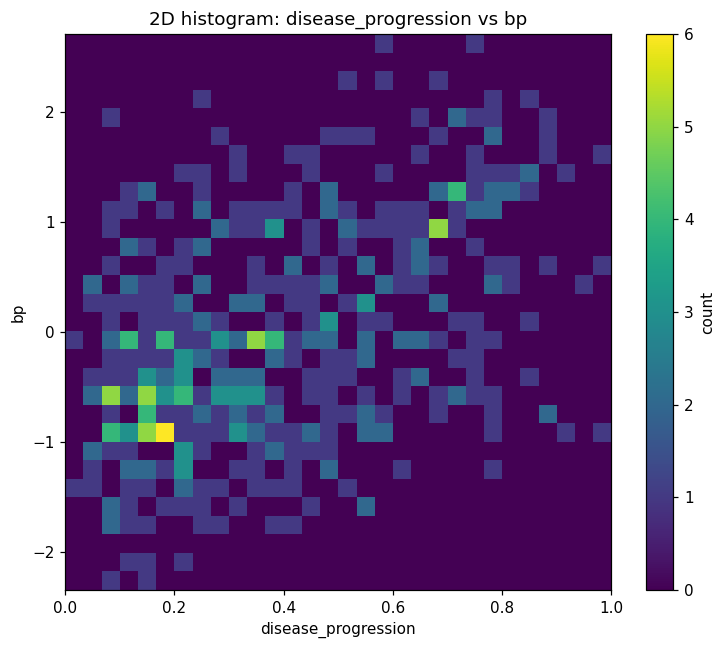

In [ ]:
try:
    import ipywidgets as _w
    _w.Widget.close_all()
except Exception:
    pass
clear_output(wait=True)


def plot_2d(fx, kx, fy, ky, bins, logscale, show_samples, show_targets):
    st = current()
    df = st["display_df"]
    samples = st["samples"]

    if kx == "continuous" and ky == "continuous":
        x = pd.to_numeric(df[fx], errors="coerce").values
        y = pd.to_numeric(df[fy], errors="coerce").values
        m = np.isfinite(x) & np.isfinite(y)
        fig, ax = plt.subplots(figsize=(7, 6))
        h = ax.hist2d(x[m], y[m], bins=bins, cmap="viridis",
                      norm=LogNorm() if logscale else None)
        fig.colorbar(h[3], ax=ax, label="count")
        ax.set_xlabel(fx)
        ax.set_ylabel(fy)
        for i, s in enumerate(samples):
            c = scolor(i)
            sx, sy = float(s["display_row"][fx]), float(s["display_row"][fy])
            if show_samples:
                ax.scatter([sx], [sy], color=c, edgecolor="white", s=90, zorder=5)
                ax.text(sx, sy, f" s{s['idx']}", color="white", fontsize=8, zorder=6)
            if show_targets and "exemplar_row" in s:
                ex, ey = float(s["exemplar_row"][fx]), float(s["exemplar_row"][fy])
                ax.scatter([ex], [ey], color=c, edgecolor="white", s=90,
                           marker="X", zorder=5)
                if show_samples:
                    ax.plot([sx, ex], [sy, ey], color=c, lw=1.5, alpha=0.8, zorder=4)
        ax.set_title(f"2D histogram: {fx} vs {fy}")
        plt.tight_layout()
        plt.show()
        return

    if kx == "categorical" and ky == "categorical":
        ct = pd.crosstab(df[fx], df[fy])
        xs, ys = list(ct.index), list(ct.columns)
        nx, ny = len(xs), len(ys)
        width = 0.8 / max(ny, 1)
        base = np.arange(nx)
        fig, ax = plt.subplots(figsize=(9, 5))
        for j, yc in enumerate(ys):
            ax.bar(base + j * width, ct[yc].values, width=width, label=f"{fy}={yc}")
        ax.set_xticks(base + 0.4 - width / 2)
        ax.set_xticklabels([str(v) for v in xs])
        ax.set_xlabel(fx)
        ax.set_ylabel("count")
        ax.legend(title=fy, fontsize=8)
        xpos = {v: i for i, v in enumerate(xs)}
        ypos = {v: j for j, v in enumerate(ys)}
        ymax = ax.get_ylim()[1]
        for i, s in enumerate(samples):
            c = scolor(i)
            sxv, syv = s["display_row"][fx], s["display_row"][fy]
            sX = None
            if show_samples and sxv in xpos and syv in ypos:
                sX = base[xpos[sxv]] + ypos[syv] * width
                ax.scatter([sX], [ymax * 0.96], color=c, marker="v", s=70, zorder=5)
                ax.text(sX, ymax * 0.99, f"s{s['idx']}", color=c,
                        ha="center", va="top", fontsize=8)
            if show_targets and "exemplar_row" in s:
                exv, eyv = s["exemplar_row"][fx], s["exemplar_row"][fy]
                if exv in xpos and eyv in ypos:
                    eX = base[xpos[exv]] + ypos[eyv] * width
                    ax.scatter([eX], [ymax * 0.86], color=c, marker="o",
                               facecolors="none", s=70, zorder=5)
                    if sX is not None:
                        ax.plot([sX, eX], [ymax * 0.91, ymax * 0.91], color=c, alpha=0.6)
        ax.set_title(f"Category counts: {fx} x {fy}")
        plt.tight_layout()
        plt.show()
        return

    cont, cat = (fx, fy) if kx == "continuous" else (fy, fx)
    cats = sorted(df[cat].dropna().unique(), key=lambda v: str(v))
    cvals = pd.to_numeric(df[cont], errors="coerce")
    lo, hi = float(np.nanmin(cvals)), float(np.nanmax(cvals))
    edges = np.linspace(lo, hi, bins + 1)
    n = len(cats)
    fig, axes = plt.subplots(n, 1, figsize=(8, 1.8 * n + 1), sharex=True)
    if n == 1:
        axes = [axes]
    for a, cv in zip(axes, cats):
        sub = cvals[df[cat] == cv].dropna().values
        a.hist(sub, bins=edges, color="#4C72B0", alpha=0.75, edgecolor="white")
        if logscale:
            a.set_yscale("log")
        a.set_ylabel(f"{cat}={cv}\ncount", fontsize=8)
        ymax = a.get_ylim()[1]
        for i, s in enumerate(samples):
            c = scolor(i)
            if show_samples and s["display_row"][cat] == cv:
                a.axvline(float(s["display_row"][cont]), color=c, ls="--", lw=1.6)
                a.text(float(s["display_row"][cont]), ymax * 0.88, f"s{s['idx']}",
                       color=c, fontsize=8, ha="center")
            if (show_targets and "exemplar_row" in s
                    and s["exemplar_row"][cat] == cv):
                a.axvline(float(s["exemplar_row"][cont]), color=c, ls=":", lw=1.6)
                a.text(float(s["exemplar_row"][cont]), ymax * 0.66, f"t{s['idx']}",
                       color=c, fontsize=8, ha="center")
    axes[-1].set_xlabel(cont)
    fig.suptitle(f"{cont} distribution per {cat} category")
    plt.tight_layout()
    plt.show()


st = current()
_feats = st["display_feature_names"]
_second = _feats[1] if len(_feats) > 1 else _feats[0]
fx_dd = widgets.Dropdown(options=_feats, value=_feats[0], description="X feat:")
kx_dd = widgets.Dropdown(options=["continuous", "categorical"], description="X kind:",
                         value=st["default_kinds"][_feats[0]])
fy_dd = widgets.Dropdown(options=_feats, value=_second, description="Y feat:")
ky_dd = widgets.Dropdown(options=["continuous", "categorical"], description="Y kind:",
                         value=st["default_kinds"][_second])
bins2_sl = widgets.IntSlider(value=30, min=5, max=80, description="Bins:")
logc_cb = widgets.Checkbox(value=False, description="log scale")
show_s2_cb = widgets.Checkbox(value=True, description="show samples")
show_t2_cb = widgets.Checkbox(value=True, description="show targets")
plot2_btn = widgets.Button(description="Plot", button_style="primary")

fx_dd.observe(lambda ch: setattr(kx_dd, "value",
              st["default_kinds"].get(ch["new"], "continuous")), names="value")
fy_dd.observe(lambda ch: setattr(ky_dd, "value",
              st["default_kinds"].get(ch["new"], "continuous")), names="value")


def _redraw_2d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([fx_dd, kx_dd]))
    display(widgets.HBox([fy_dd, ky_dd]))
    display(widgets.HBox([bins2_sl, logc_cb]))
    display(widgets.HBox([show_s2_cb, show_t2_cb, plot2_btn]))
    if make_plot:
        plot_2d(fx_dd.value, kx_dd.value, fy_dd.value, ky_dd.value, bins2_sl.value,
                logc_cb.value, show_s2_cb.value, show_t2_cb.value)


def _on_plot_2d(_=None):
    _redraw_2d(make_plot=True)


plot2_btn.on_click(_on_plot_2d)
_redraw_2d(make_plot=False)


## 4. Priorities analysis

This is the core of the notebook: author priorities for the loaded dataset, then see how
they cover it. The next cell holds a plain `PRIORITIES` dict with the **same structure as
`priority_sets.py`** so you can copy it straight back there.

* Numerical features -> a function `value -> [0, 1]` (`constant_priority`,
  `linear_priority`, `exponential_priority`, `interval_priority`, a custom callable, or
  `NON_ACTIONABLE`). Wrap with `numerical_entry(fn, min_val=..., max_val=...)` to set
  bounds.
* Categorical features -> a `{code: weight}` mapping (0 = forbidden).

Priorities operate in the **preprocessed** space (numericals standard-scaled), regardless
of the view mode you picked above. Run `print_priority_skeleton()` to get a ready-to-fill
template for the currently loaded dataset.

In [ ]:
# === EDIT ME: priorities for the loaded dataset (same shape as priority_sets.py) ===
# Note: diabetes numericals are standard-scaled (~[-3, 3]).
PRIORITIES = {
    "numerical": {
        "age": constant_priority(0.5),
        "bmi": linear_priority(x0=-2.0, x1=2.0, increasing=False),   # prefer lower bmi
        "bp": linear_priority(x0=-2.0, x1=2.0, increasing=False),    # prefer lower bp
        "s1": constant_priority(0.5),
        "s2": constant_priority(0.5),
        "s3": constant_priority(0.5),
        "s4": constant_priority(0.5),
        "s5": exponential_priority(x0=-2.0, x1=2.0, increasing=False, a=5.0),
        "s6": constant_priority(0.5),
    },
    "categorical": {
        "sex": {0: 1.0, 1: 0.5},
    },
}


def print_priority_skeleton():
    st = current()
    print("PRIORITIES = {")
    print('    "numerical": {')
    for f in st["numerical_features"]:
        print(f'        "{f}": constant_priority(0.5),')
    print("    },")
    print('    "categorical": {')
    for name, g in st["categorical_groups"].items():
        body = ", ".join(f"{c}: 1.0" for c in g["categories"])
        print(f'        "{name}": {{{body}}},')
    print("    },")
    print("}")

In [ ]:
try:
    import ipywidgets as _w
    _w.Widget.close_all()
except Exception:
    pass
clear_output(wait=True)


def materialize_priorities(prio_spec, sample_idx):
    st = current()
    ctx = st["ctx"]
    PRIORITY_SETS.setdefault(ctx.dataset_key, {})["__notebook__"] = prio_spec
    sample = st["pre_matrix"][int(sample_idx)]
    return build_priorities(ctx, "__notebook__", sample)


def _group_by_indices(indices):
    st = current()
    for name, g in st["categorical_groups"].items():
        if tuple(g["indices"]) == tuple(indices):
            return name, g
    return None, None


def _eval_fn(fn, x):
    return float(np.ravel(fn(float(x)))[0])


def evaluate_preferences(priorities, X, agg):
    n = X.shape[0]
    feats = []
    for idx, cfg in priorities["numerical"].items():
        col = X[:, idx]
        fn = cfg.get("function")
        if fn is None:
            lo, hi = cfg["min"], cfg["max"]
            v = np.where((col >= lo - 1e-9) & (col <= hi + 1e-9), 1.0, 0.0)
        else:
            v = np.clip(np.array([_eval_fn(fn, x) for x in col]), 0.0, 1.0)
        feats.append(v)
    for indices, mapping in priorities["categorical"].items():
        idxs = list(indices)
        maxw = max(mapping.values()) or 1.0
        sub = X[:, idxs]
        vals = []
        for r in sub:
            key = tuple(1.0 if val >= 0.5 else 0.0 for val in r)
            w = mapping.get(key, 0.0)
            vals.append(w / maxw if maxw > 0 else 0.0)
        feats.append(np.array(vals))
    M = np.vstack(feats) if feats else np.ones((1, n))
    if agg == "product":
        a = np.prod(M, axis=0)
    elif agg == "min":
        a = np.min(M, axis=0)
    else:
        a = np.mean(M, axis=0)
    return a, M


def global_space_pct(coverages):
    frac = 1.0
    for c in coverages:
        frac *= max(c.allowed_space_pct, 0.0) / 100.0
    return frac * 100.0


def plot_priority_numerical(idx, cfg, cov):
    st = current()
    col = st["pre_matrix"][:, idx]
    name = st["feature_names"][idx]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.hist(col, bins=30, color="#BBBBBB", alpha=0.7, edgecolor="white")
    ax.set_xlabel(name + " (preprocessed)")
    ax.set_ylabel("count")
    ax2 = ax.twinx()
    ax2.set_ylabel("priority")
    ax2.set_ylim(-0.05, 1.05)
    fn = cfg.get("function")
    if fn is None:
        ax.axvline(cfg["min"], color="#C44E52", lw=2.0)
        ax2.text(0.02, 0.9, "non-actionable (fixed)", transform=ax2.transAxes,
                 color="#C44E52", fontsize=9)
    else:
        xs = np.linspace(float(col.min()), float(col.max()), 400)
        ys = np.array([_eval_fn(fn, x) for x in xs])
        ax2.plot(xs, ys, color="#C44E52", lw=2.0, label="priority f(x)")
        ax2.legend(loc="upper right", fontsize=8)
    ax.axvline(cov.bounds_min, color="green", ls="--", lw=1.2)
    ax.axvline(cov.bounds_max, color="green", ls="--", lw=1.2)
    for a, b in cov.allowed_intervals:
        ax.axvspan(a, b, color="green", alpha=0.08)
    ax.set_title(f"{name}: space {cov.allowed_space_pct:.1f}% | "
                 f"points {cov.allowed_points_pct:.1f}%")
    plt.tight_layout()
    plt.show()


def plot_priority_categorical(indices, mapping, group_name, group):
    st = current()
    X = st["pre_matrix"]
    cats = list(group["categories"])
    srcs = group["source_values"]
    idxs = list(group["indices"])
    counts = [int(np.sum(X[:, c] >= 0.5)) for c in idxs]
    code_weight = {}
    for one_hot, w in mapping.items():
        code_weight[cats[int(np.argmax(one_hot))]] = w
    weights = [code_weight.get(c, 0.0) for c in cats]
    labels = [f"{c}\n({srcs[i]})" for i, c in enumerate(cats)]
    xpos = np.arange(len(cats))
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(xpos, counts, color="#55A868", alpha=0.85)
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("count")
    ax.set_xlabel(group_name)
    ax2 = ax.twinx()
    ax2.plot(xpos, weights, "o-", color="#C44E52")
    ax2.set_ylim(-0.05, max(1.05, max(weights) + 0.05) if weights else 1.05)
    ax2.set_ylabel("priority weight")
    for x, w in zip(xpos, weights):
        ax2.text(x, w, f" {w:g}", color="#C44E52", va="bottom", fontsize=8)
    ax.set_title(f"{group_name}: counts + priority weights")
    plt.tight_layout()
    plt.show()


def analyze_priorities_ui(prio_spec, sample_idx, agg, pref_range):
    st = current()
    priorities = materialize_priorities(prio_spec, sample_idx)
    coverages, global_pct, n = compute_priority_coverage(
        priorities, st["pre_matrix"], feature_names=st["feature_names"],
    )
    print(format_coverage_report(coverages, global_pct, n))
    print()
    print(f"Approx. global allowed hyper-space (product of per-feature space): "
          f"{global_space_pct(coverages):.4f}%")
    a, _ = evaluate_preferences(priorities, st["pre_matrix"], agg)
    lo, hi = pref_range
    mask = (a >= lo) & (a <= hi)
    allowed = a > 0
    print(f"Allowed points (aggregate {agg} > 0): "
          f"{100 * allowed.mean():.2f}% ({int(allowed.sum())}/{len(a)})")
    print(f"Points with aggregate {agg} in [{lo:.2f}, {hi:.2f}]: "
          f"{100 * mask.mean():.2f}% ({int(mask.sum())}/{len(a)})")

    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.hist(a, bins=30, color="#8172B3", alpha=0.85, edgecolor="white")
    ax.axvspan(lo, hi, color="green", alpha=0.15)
    ax.set_xlabel(f"aggregate preference ({agg})")
    ax.set_ylabel("count")
    ax.set_title("Dataset preference distribution (green = selected range)")
    plt.tight_layout()
    plt.show()

    cov_by_idx = {c.index: c for c in coverages}
    for idx in sorted(priorities["numerical"].keys()):
        if idx in cov_by_idx:
            plot_priority_numerical(idx, priorities["numerical"][idx], cov_by_idx[idx])
    for indices, mapping in priorities["categorical"].items():
        name, g = _group_by_indices(indices)
        if g is not None:
            plot_priority_categorical(indices, mapping, name, g)


st = current()
_n = len(st["display_df"])
sample_idx_w = widgets.BoundedIntText(value=0, min=0, max=max(_n - 1, 0),
                                      description="Sample idx:")
agg_w = widgets.Dropdown(options=["product", "min", "mean"], value="product",
                         description="Aggregate:")
pref_w = widgets.FloatRangeSlider(value=[0.001, 1.0], min=0.0, max=1.0, step=0.01,
                                  description="Pref range:", readout_format=".2f",
                                  continuous_update=False)
prio_btn = widgets.Button(description="Analyze priorities", button_style="primary")


def _redraw_prio(make_run=False):
    clear_output(wait=True)
    display(widgets.HBox([sample_idx_w, agg_w]))
    display(pref_w)
    display(prio_btn)
    if make_run:
        try:
            analyze_priorities_ui(PRIORITIES, sample_idx_w.value, agg_w.value,
                                  tuple(pref_w.value))
        except Exception as exc:
            print("Error:", exc)


def _on_prio(_=None):
    _redraw_prio(make_run=True)


prio_btn.on_click(_on_prio)
_redraw_prio(make_run=True)
